In [1]:
# Imports
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
import pandas as pd
import geopandas as gpd
import fiona
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
import matplotlib as mpl

Loading Costs Data (pyCIAM Model)

In [2]:
# Load the zarr file as xarray dataset
zarr_path = Path("./pyCIAM_outputs.zarr")
ds = xr.open_zarr(zarr_path).sel(year=slice(2015, 2100))
ds

<xarray.Dataset> Size: 2GB
Dimensions:       (case: 11, costtype: 6, adm1: 1836, scenario: 5, quantile: 1,
                   year: 86, ssp: 5, iam: 2, seg: 9568)
Coordinates:
  * case          (case) <U12 528B 'noAdaptation' 'protect10' ... 'optimalfixed'
  * costtype      (costtype) <U15 360B 'wetland' ... 'stormPopulation'
  * adm1          (adm1) <U8 59kB 'ABW' 'AGO.11_1' ... 'ZNC.3_1' 'ZNC.4_1'
  * scenario      (scenario) <U17 340B 'SSP126' 'SSP245' ... 'ncc_regional_rise'
  * quantile      (quantile) float64 8B 0.5
  * year          (year) int32 344B 2015 2016 2017 2018 ... 2097 2098 2099 2100
  * ssp           (ssp) <U4 80B 'SSP1' 'SSP2' 'SSP3' 'SSP4' 'SSP5'
  * iam           (iam) <U5 40B 'IIASA' 'OECD'
  * seg           (seg) <U9 344kB 'seg_00001' 'seg_00002' ... 'seg_99019'
Data variables:
    costs         (case, costtype, adm1, scenario, quantile, year, ssp, iam) float32 2GB dask.array<chunksize=(11, 6, 9, 5, 1, 10, 5, 2), meta=np.ndarray>
    optimal_case  (seg, scenario, quantile, ssp, iam) uint8 478kB dask.array<chunksize=(9568, 5, 1, 5, 2), meta=np.ndarray>
Attributes:
    description:                  pyCIAM run with regional rise SLR data mapp...
    planning_period_start_years:  [2005, 2010, 2020, 2030, 2040, 2050, 2060, ...
    updated:                      Thu Feb 12 16:54:07 2026

Load Regional Sea Level Rise (RSLR) Data (BRICK framework)

In [3]:
# SSP1-2.6
ssp126_ds = xr.open_dataset("./regional_rise/slr_ssp126.nc")
ssp126_slr = (ssp126_ds["slr"].sel(time=2100) - ssp126_ds["slr"].sel(time=2015)) / 10
# SSP2-4.5
ssp245_ds = xr.open_dataset("./regional_rise/slr_ssp245.nc")
ssp245_slr = (ssp245_ds["slr"].sel(time=2100) - ssp245_ds["slr"].sel(time=2015)) / 10
# SSP3-7.0
ssp370_ds = xr.open_dataset("./regional_rise/slr_ssp370.nc")
ssp370_slr = (ssp370_ds["slr"].sel(time=2100) - ssp370_ds["slr"].sel(time=2015)) / 10
# SSP5-8.5
ssp585_ds = xr.open_dataset("./regional_rise/slr_ssp585.nc")
ssp585_slr = (ssp585_ds["slr"].sel(time=2100) - ssp585_ds["slr"].sel(time=2015)) / 10

SSP2-4.5 Sea Level Rise Weighted Global Mean

In [4]:
# Latitude weights
weights_ssp245 = np.cos(np.deg2rad(ssp245_slr.lat))
# Normalize weights
weights_ssp245 = weights_ssp245 / weights_ssp245.mean()
# Global mean sea level rise
global_mean_ssp245 = ssp245_slr.weighted(weights_ssp245).mean(("lat", "lon"))
print(global_mean_ssp245.values)

0.5116619160642445


SSP2-4.5 RSRL Plotted

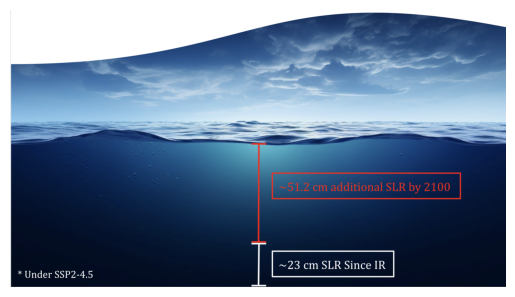

In [5]:
import matplotlib.image as mpimg
image = mpimg.imread("./SSP2-4.5_SLR_DV.png")
plt.imshow(image)
plt.axis("off")
plt.show()

Bar Plot of Sea Level Rise (Weighted Global Mean) and Total Cost for different SSPs

In [6]:
# Global Mean (Weighted) Sea Level Rise

# Latitude weights
weights_ssp126 = np.cos(np.deg2rad(ssp126_slr.lat))
weights_ssp245 = np.cos(np.deg2rad(ssp245_slr.lat))
weights_ssp370 = np.cos(np.deg2rad(ssp370_slr.lat))
weights_ssp585 = np.cos(np.deg2rad(ssp585_slr.lat))
# Normalize weights
weights_ssp126 = weights_ssp126 / weights_ssp126.mean()
weights_ssp245 = weights_ssp245 / weights_ssp245.mean()
weights_ssp370 = weights_ssp370 / weights_ssp370.mean()
weights_ssp585 = weights_ssp585 / weights_ssp585.mean()
# Global mean sea level rise
global_mean_ssp126 = float(ssp126_slr.weighted(weights_ssp126).mean(("lat", "lon")))
global_mean_ssp245 = float(ssp245_slr.weighted(weights_ssp245).mean(("lat", "lon")))
global_mean_ssp370 = float(ssp370_slr.weighted(weights_ssp370).mean(("lat", "lon")))
global_mean_ssp585 = float(ssp585_slr.weighted(weights_ssp585).mean(("lat", "lon")))

In [7]:
# Total Costs * Based on Protect10 Scenario
# Total Economic Cost SSP1-2.6
cost_ssp126 = (
    ds.costs.isel(case=1, scenario=0, ssp=0, iam=0, quantile=0)
    .sum(dim=["year", "costtype", "adm1"])
)
total_cost_ssp126 = float(cost_ssp126.compute())
# Total Economic Cost SSP2-4.5
cost_ssp245 = (
    ds.costs.isel(case=1, scenario=1, ssp=1, iam=0, quantile=0)
    .sum(dim=["year", "costtype", "adm1"])
)
total_cost_ssp245 = float(cost_ssp245.compute())
# Total Economic Cost SSP3-7.0
cost_ssp370 = (
    ds.costs.isel(case=1, scenario=2, ssp=2, iam=0, quantile=0)
    .sum(dim=["year", "costtype", "adm1"])
)
total_cost_ssp370 = float(cost_ssp370.compute())
# Total Economic Cost SSP5-8.5
cost_ssp585 = (
    ds.costs.isel(case=1, scenario=3, ssp=4, iam=0, quantile=0)
    .sum(dim=["year", "costtype", "adm1"])
)
total_cost_ssp585 = float(cost_ssp585.compute())

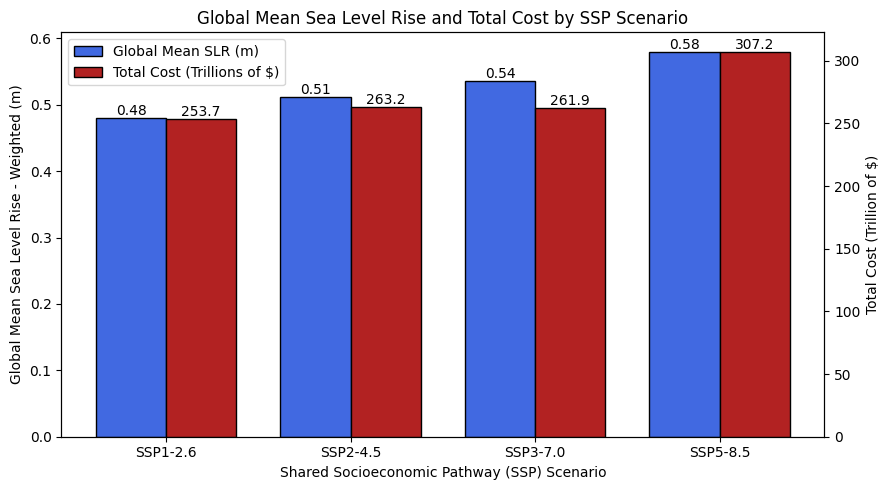

In [8]:
# Scenario labels
scenarios = ["SSP1-2.6", "SSP2-4.5", "SSP3-7.0", "SSP5-8.5"]
# Global Mean (Weighted) Sea Level Rise
slr_vals = [global_mean_ssp126, global_mean_ssp245, global_mean_ssp370, global_mean_ssp585]
# Costs in Trillions of Dollars
cost_vals = [float(total_cost_ssp126) / 1e12, float(total_cost_ssp245) / 1e12, 
             float(total_cost_ssp370) / 1e12, float(total_cost_ssp585) / 1e12]

# Plot Specifications
x = np.arange(len(scenarios))
width = 0.38
fig, ax1 = plt.subplots(figsize=(9, 5))

# Left axis: sea level rise (BLUE)
bars1 = ax1.bar(
    x - width/2,
    slr_vals,
    width,
    label="Global Mean SLR (m)",
    color="royalblue",
    edgecolor="black",
    linewidth=1
)

ax1.set_ylabel("Global Mean Sea Level Rise - Weighted (m)")
ax1.set_xticks(x)
ax1.set_xticklabels(scenarios)
ax1.set_title("Global Mean Sea Level Rise and Total Cost by SSP Scenario")

# Right axis: costs (RED)
ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + width/2,
    cost_vals,
    width,
    label="Total Cost (Trillions of $)",
    color="firebrick",
    edgecolor="black",
    linewidth=1
)

# Axis Labels
ax2.set_ylabel("Total Cost (Trillion of $)")
ax1.set_xlabel("Shared Socioeconomic Pathway (SSP) Scenario")

# Add value labels
for bar in bars1:
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f"{h:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

for bar in bars2:
    h = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f"{h:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")

# Plot
plt.tight_layout()
plt.show()

Cloropleth Graph SLR (SSP2-4.5) - Total SLR and Costs by 2100

In [9]:
# Create GDF
# Load GADM level 1. Use local file if present; else download only countries in PyCIAM adm1.
# Create gadm folder if it doesn't exist
gadm_dir = Path("gadm")
gadm_dir.mkdir(exist_ok=True)

gadm_path = gadm_dir / "gadm_410.gpkg"
if not gadm_path.exists():
    gadm_path = gadm_dir / "gadm_410-level1.gpkg"
if not gadm_path.exists():
    import urllib.request
    import zipfile
    # Unique country codes from adm1 (GID_0: part before "." or full if no dot, e.g. ABW or AGO)
    adm1_codes = [str(x) for x in ds.adm1.values]
    gid0_set = set()
    for c in adm1_codes:
        if "." in c:
            gid0_set.add(c.split(".")[0])
        else:
            gid0_set.add(c[:3] if len(c) >= 3 else c)
    base_url = "https://geodata.ucdavis.edu/gadm/gadm4.1/gpkg"
    gdf_list = []
    for gid0 in sorted(gid0_set):
        url = f"{base_url}/gadm41_{gid0}.gpkg"
        try:
            path = gadm_dir / f"gadm41_{gid0}.gpkg"
            if not path.exists():
                urllib.request.urlretrieve(url, path)
            layers = fiona.listlayers(str(path))
            l1 = "level1" if "level1" in layers else (layers[1] if len(layers) > 1 else layers[0])
            gdf_list.append(gpd.read_file(path, layer=l1))
        except Exception:
            pass  # skip missing or failed countries
    if not gdf_list:
        raise FileNotFoundError(
            "GADM level-1 not found and auto-download failed. Save gadm_410.gpkg from "
            "https://gadm.org/download_world.html in the gadm folder, or check your connection."
        )
    gdf = pd.concat(gdf_list, ignore_index=True)
else:
    layers = fiona.listlayers(str(gadm_path))
    level1_name = "level1" if "level1" in layers else (layers[1] if len(layers) > 1 else layers[0])
    gdf = gpd.read_file(gadm_path, layer=level1_name)

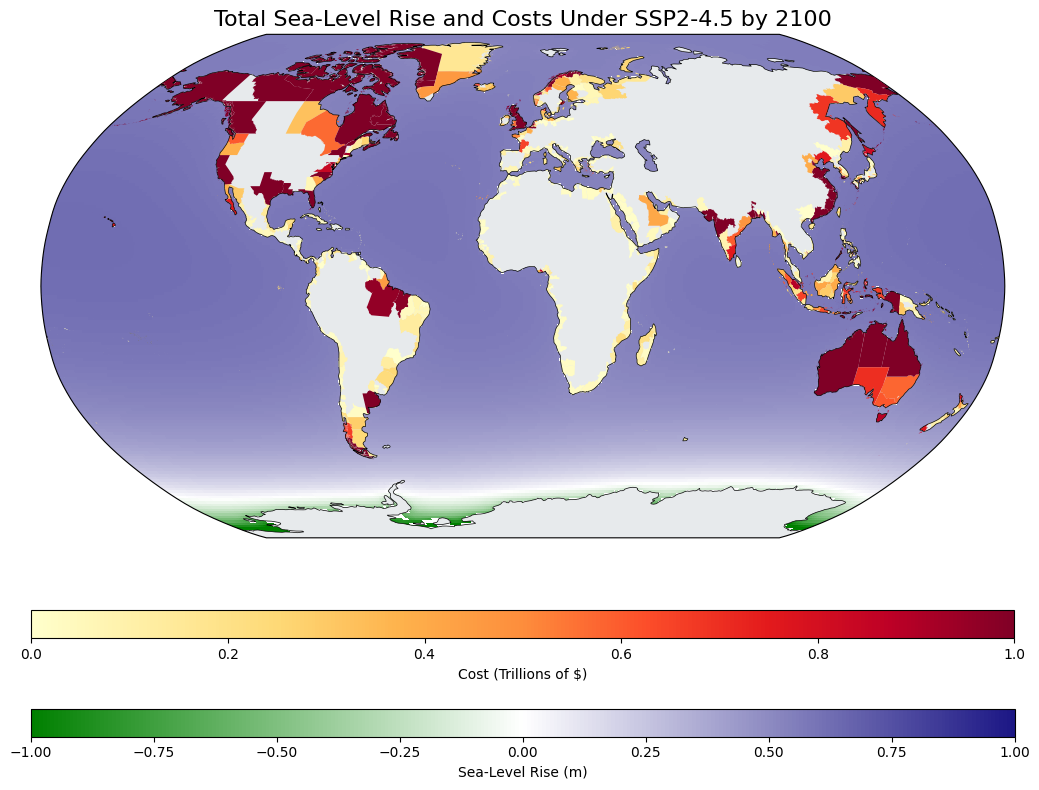

In [10]:
# SLR Coordinates
lon, lat = ssp245_ds["lon"].values, ssp245_ds["lat"].values
longitude, latitude = np.meshgrid(lon, lat)

# Cost under SSP 245 by 2100
cost_245 = (
    ds.costs.isel(case=1, scenario=1, ssp=1, iam=0, quantile=0)
    .sum(dim=["year", "costtype"])
    .assign_coords(adm1=ds.adm1.values)
)
# Cost values to series
cost_series = {
    str(ds.adm1.values[i]): float(cost_245.isel(adm1=i).values)
    for i in range(cost_245.sizes["adm1"])
}
# Convert cost values to df
diff_df = pd.DataFrame(
    [{"GID_1": k, "cost_245": v} for k, v in cost_series.items() if np.isfinite(v)]
)

# Merge cost data with gdf
gdf = gdf.merge(diff_df, on="GID_1", how="left")
gdf["cost_245"] = gdf["cost_245"].fillna(0)
gdf["cost_245_plot"] = gdf["cost_245"].clip(lower=0) / 1e12
gdf["geometry"] = gdf.geometry.simplify(0.03, preserve_topology=True)

# Plotting
vm = 1

fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

# Ocean / SLR layer
slr_cmap = LinearSegmentedColormap.from_list(
    "green_white_blue",
    ["green", "white", "#1c1785"]
)
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

# Color
pcm = ax.pcolormesh(
    longitude,
    latitude,
    ssp245_slr.values,
    transform=ccrs.PlateCarree(),
    cmap=slr_cmap,
    norm=norm,
    zorder=1
)

# Draw land background above SLR
ax.add_feature(cfeature.LAND, facecolor="#E7EAEC", edgecolor="none", zorder=2)

# Cost layer on top of land
gdf_nonzero = gdf[gdf["cost_245_plot"] > 0].copy()

gdf_nonzero.plot(
    ax=ax,
    column="cost_245_plot",
    cmap="YlOrRd",
    vmin=0,
    vmax=vm,
    transform=ccrs.PlateCarree(),
    edgecolor="none",
    linewidth=0.2,
    zorder=3
)

# Coastlines
ax.coastlines(linewidth=0.5, zorder=4)

ax.set_title("Total Sea-Level Rise and Costs Under SSP2-4.5 by 2100", fontsize=16)

# SLR colorbar
cbar1 = plt.colorbar(
    pcm,
    ax=ax,
    orientation="horizontal",
    pad=0.1,
    fraction=0.04,
    aspect=35
)
cbar1.set_label("Sea-Level Rise (m)")

# Cost colorbar
norm2 = mpl.colors.Normalize(vmin=0, vmax=vm)
sm2 = mpl.cm.ScalarMappable(norm=norm2, cmap="YlOrRd")
sm2.set_array([])

cbar2 = plt.colorbar(
    sm2,
    ax=ax,
    orientation="horizontal",
    pad=0.12,
    fraction=0.0465,
    aspect=35
)
cbar2.set_label("Cost (Trillions of $)")

plt.tight_layout()
plt.show()

Table of Annual Sea Level Rise and Costs

In [11]:
florida = gdf[gdf["NAME_1"] == "Florida"]
minx, miny, maxx, maxy = florida.total_bounds
slr126_fl = ssp126_ds["slr"].sel(
    lat=slice(miny, maxy),
    lon=slice(minx % 360, maxx % 360)
)

slr585_fl = ssp585_ds["slr"].sel(
    lat=slice(miny, maxy),
    lon=slice(minx % 360, maxx % 360)
)
weights126 = np.cos(np.deg2rad(slr126_fl.lat))
weights585 = np.cos(np.deg2rad(slr585_fl.lat))
slr126_fl_avg = slr126_fl.weighted(weights126).mean(("lat","lon"))
slr585_fl_avg = slr585_fl.weighted(weights585).mean(("lat","lon"))
slr126_fl_annual = slr126_fl_avg.diff("time")
slr585_fl_annual = slr585_fl_avg.diff("time")
florida_ssp126_min_slr = np.min(slr126_fl_annual.values) * 100
florida_ssp126_max_slr = np.max(slr126_fl_annual.values) * 100
florida_ssp126_mean_slr = np.mean(slr126_fl_annual.values) * 100

florida_ssp585_min_slr = np.min(slr585_fl_annual.values) * 100
florida_ssp585_max_slr = np.max(slr585_fl_annual.values) * 100
florida_ssp585_mean_slr = np.mean(slr585_fl_annual.values) * 100

florida_ssp126_total = (slr126_fl_avg.sel(time=2100) - slr126_fl_avg.sel(time=2015)).item() / 10
florida_ssp585_total = (slr585_fl_avg.sel(time=2100) - slr585_fl_avg.sel(time=2015)).item() / 10
florida_ssp126 = [
    florida_ssp126_min_slr,
    florida_ssp126_max_slr,
    florida_ssp126_mean_slr,
    florida_ssp126_total
]

florida_ssp585 = [
    florida_ssp585_min_slr,
    florida_ssp585_max_slr,
    florida_ssp585_mean_slr,
    florida_ssp585_total
]


In [12]:
cost_best_annual = (
    ds.costs.isel(case=-1, scenario=0, ssp=0, iam=0, quantile=0)
    .sum(dim=["costtype"])
)

cost_worst_annual = (
    ds.costs.isel(case=6, scenario=-2, ssp=-1, iam=0, quantile=0)
    .sum(dim=["costtype"])
)
fl_code = "USA.10_1"
cost_best_annual = (
    ds.costs.isel(case=-1, scenario=0, ssp=0, iam=0, quantile=0)
    .sum(dim=["costtype"])
    .assign_coords(adm1=ds.adm1.values)
)

cost_worst_annual = (
    ds.costs.isel(case=6, scenario=-2, ssp=-1, iam=0, quantile=0)
    .sum(dim=["costtype"])
    .assign_coords(adm1=ds.adm1.values)
)

cost_best_fl = cost_best_annual.sel(adm1=fl_code)
cost_worst_fl = cost_worst_annual.sel(adm1=fl_code)

cost_fl_df = pd.DataFrame({
    "year": cost_best_fl.year.values,
    "best_case_cost": cost_best_fl.values,
    "worst_case_cost": cost_worst_fl.values
})
florida_ssp126_costs = [min(cost_fl_df["best_case_cost"]) / 1e12, max(cost_fl_df["best_case_cost"]) / 1e12, 
                        cost_fl_df["best_case_cost"].mean() / 1e12, cost_fl_df["best_case_cost"].sum() / 1e12]
florida_ssp126.extend(florida_ssp126_costs)
florida_ssp585_costs = [min(cost_fl_df["worst_case_cost"]) / 1e12, max(cost_fl_df["worst_case_cost"]) / 1e12,
                        cost_fl_df["worst_case_cost"].mean() / 1e12, cost_fl_df["worst_case_cost"].sum() / 1e12]
florida_ssp585.extend(florida_ssp585_costs)
pd.DataFrame(
    [florida_ssp126, florida_ssp585],
    index=["SSP126", "SSP585"],
    columns=[
        "Min SLR (mm/yr)",
        "Max SLR (mm/yr)",
        "Mean SLR (mm/yr)",
        "Total SLR (m)",
        "Min Cost ($T/yr)",
        "Max Cost ($T/yr)",
        "Mean Cost ($T/yr)",
        "Total Cost ($T)"
    ]
)

,Min SLR (mm/yr),Max SLR (mm/yr),Mean SLR (mm/yr),Total SLR (m),Min Cost ($T/yr),Max Cost ($T/yr),Mean Cost ($T/yr),Total Cost ($T)
SSP126,5.737669,6.979601,6.346524,0.539455,0.001526,0.024949,0.009366,0.805462
SSP585,6.013827,9.813347,7.639689,0.649374,0.001240,0.194726,0.068230,5.867773


Sea Level Rise SSP2-4.5

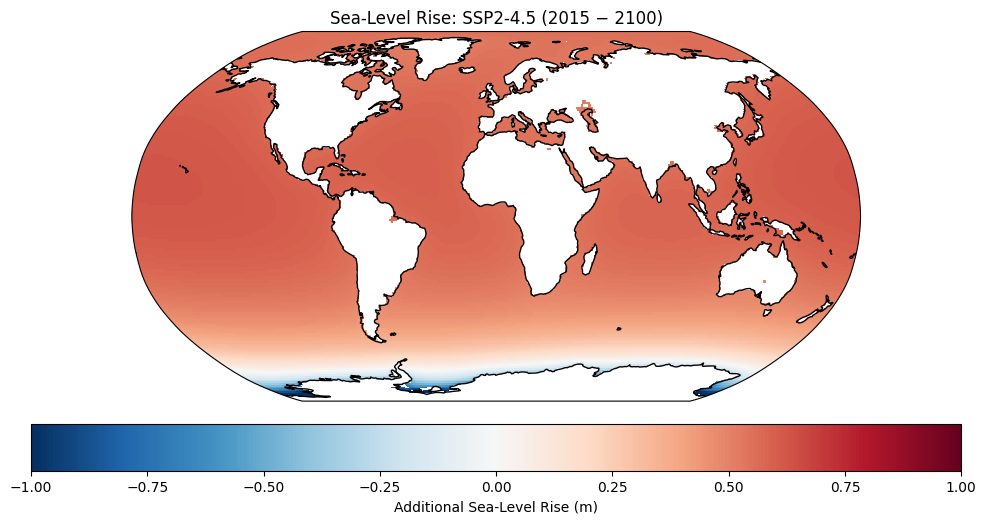

In [13]:
# Obtain Latitude and Longitudinal Values
lon, lat = ssp245_ds["lon"].values, ssp245_ds["lat"].values
longitude, latitude = np.meshgrid(lon, lat)

#Plot Specifications
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson())
pcm = ax.pcolormesh(
    longitude,
    latitude,
    ssp245_slr.values,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)

# Labels
ax.coastlines()
ax.set_title("Sea-Level Rise: SSP2-4.5 (2015 − 2100)")
cbar = plt.colorbar(pcm, orientation="horizontal", pad=0.05)
cbar.set_label("Additional Sea-Level Rise (m)")

# Plot
plt.show()

Cloropleth Graph SLR (SSP2-4.5) - Costs

Cloropleth Graph Costs - Difference between Worst-Case vs. Optimal Scenario

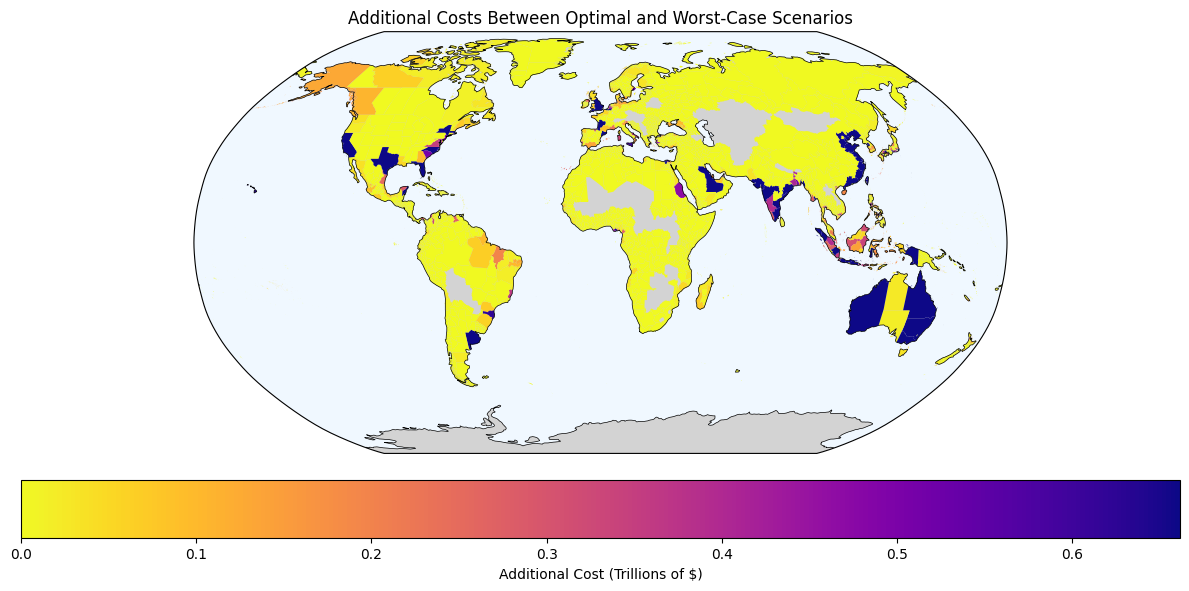

In [14]:
import geopandas as gpd
import pandas as pd
import fiona

# Optimal Scenario
cost_best = (
    ds.costs.isel(case=-1, scenario=0, ssp=0, iam=0, quantile=0)
    .sum(dim=["year", "costtype"])
    .assign_coords(adm1=ds.adm1.values)
)
cost_worst = (
    ds.costs.isel(case=6, scenario=-2, ssp=-1, iam=0, quantile=0)
    .sum(dim=["year", "costtype"])
    .assign_coords(adm1=ds.adm1.values)
)
cost_diff = (cost_worst - cost_best).load()

# Build table: adm1 (GADM GID_1) -> cost difference
diff_series = {str(ds.adm1.values[i]): float(cost_diff.isel(adm1=i).values) for i in range(cost_diff.sizes["adm1"])}
diff_df = pd.DataFrame([{"GID_1": k, "cost_diff": v} for k, v in diff_series.items() if np.isfinite(v)])

# Load GADM level 1. Use local file if present; else download only countries in PyCIAM adm1.
# Create gadm folder if it doesn't exist
gadm_dir = Path("gadm")
gadm_dir.mkdir(exist_ok=True)

gadm_path = gadm_dir / "gadm_410.gpkg"
if not gadm_path.exists():
    gadm_path = gadm_dir / "gadm_410-level1.gpkg"
if not gadm_path.exists():
    import urllib.request
    import zipfile
    # Unique country codes from adm1 (GID_0: part before "." or full if no dot, e.g. ABW or AGO)
    adm1_codes = [str(x) for x in ds.adm1.values]
    gid0_set = set()
    for c in adm1_codes:
        if "." in c:
            gid0_set.add(c.split(".")[0])
        else:
            gid0_set.add(c[:3] if len(c) >= 3 else c)
    base_url = "https://geodata.ucdavis.edu/gadm/gadm4.1/gpkg"
    gdf_list = []
    for gid0 in sorted(gid0_set):
        url = f"{base_url}/gadm41_{gid0}.gpkg"
        try:
            path = gadm_dir / f"gadm41_{gid0}.gpkg"
            if not path.exists():
                urllib.request.urlretrieve(url, path)
            layers = fiona.listlayers(str(path))
            l1 = "level1" if "level1" in layers else (layers[1] if len(layers) > 1 else layers[0])
            gdf_list.append(gpd.read_file(path, layer=l1))
        except Exception:
            pass  # skip missing or failed countries
    if not gdf_list:
        raise FileNotFoundError(
            "GADM level-1 not found and auto-download failed. Save gadm_410.gpkg from "
            "https://gadm.org/download_world.html in the gadm folder, or check your connection."
        )
    gdf = pd.concat(gdf_list, ignore_index=True)
else:
    layers = fiona.listlayers(str(gadm_path))
    level1_name = "level1" if "level1" in layers else (layers[1] if len(layers) > 1 else layers[0])
    gdf = gpd.read_file(gadm_path, layer=level1_name)

# Join PyCIAM cost difference to GADM (PyCIAM adm1 = GADM GID_1)
gdf = gdf.merge(diff_df, on="GID_1", how="left")
gdf["cost_diff"] = gdf["cost_diff"].fillna(0)
# Clip to non-negative for display (0 = no additional cost)
gdf["cost_diff_plot"] = gdf["cost_diff"].clip(lower=0) / 1e12  # convert to trillions of dollars
# Simplify geometries for much faster plotting (tolerance ~0.03 deg at equator)
gdf["geometry"] = gdf.geometry.simplify(0.03, preserve_topology=True)

# Scale so most regions get visible color (use 95th percentile to avoid a few extremes making everything yellow)
positive = gdf["cost_diff_plot"][gdf["cost_diff_plot"] > 0]
vm = float(positive.quantile(0.95)) if len(positive) > 0 else 1.0
if vm <= 0:
    vm = float(gdf["cost_diff_plot"].max()) or 1.0

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue")
ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="none")
gdf.plot(
    ax=ax, column="cost_diff_plot", cmap="plasma_r", vmin=0, vmax=vm,
    transform=ccrs.PlateCarree(), edgecolor="none", linewidth=0.2,
    legend=True, legend_kwds={"orientation": "horizontal", "pad": 0.05, "label": "Additional Cost (Trillions of $)"},
    rasterized=True
)
ax.coastlines(linewidth=0.5)
ax.set_title("Additional Costs Between Optimal and Worst-Case Scenarios")
plt.tight_layout()
plt.show()